# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [57]:
#%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [58]:
#%pip install --upgrade plotly

### Import Statements

In [59]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [60]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [61]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [62]:
df_data.shape

(4324, 9)

In [63]:
df_data.columns.values

array(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'], dtype=object)

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data.

In [64]:
print(df_data.isna().sum())

Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64


In [65]:
df_data.duplicated().sum()

np.int64(0)

In [66]:
df_data.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], inplace=True)
df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [67]:
df_data['Price'] = df_data['Price'].astype(str).str.replace(',', '', regex=False)
df_data['Price'] = pd.to_numeric(df_data['Price'], errors='coerce')

In [68]:
df_data['DateTime'] = pd.to_datetime(df_data['Date'], utc=True, format='mixed')
df_data['Year'] = df_data['DateTime'].dt.year
df_data['Month'] = df_data['DateTime'].dt.month_name()

In [69]:
print("Data after cleaning 'Price' and parsing 'Date':")
df_data.info()
df_data.head()

Data after cleaning 'Price' and parsing 'Date':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Organisation    4324 non-null   object             
 1   Location        4324 non-null   object             
 2   Date            4324 non-null   object             
 3   Detail          4324 non-null   object             
 4   Rocket_Status   4324 non-null   object             
 5   Price           964 non-null    float64            
 6   Mission_Status  4324 non-null   object             
 7   DateTime        4324 non-null   datetime64[ns, UTC]
 8   Year            4324 non-null   int32              
 9   Month           4324 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(1), int32(1), object(7)
memory usage: 321.1+ KB


,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,DateTime,Year,Month
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,2020-08-07 05:12:00+00:00,2020,August
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,2020-08-06 04:01:00+00:00,2020,August
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,2020-08-04 23:57:00+00:00,2020,August
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,2020-07-30 21:25:00+00:00,2020,July
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success,2020-07-30 11:50:00+00:00,2020,July


## Descriptive Statistics

In [70]:
df_data.describe()

,Price,Year
count,964.00,"4,324.00"
mean,153.79,"1,987.39"
std,288.45,18.07
min,5.30,"1,957.00"
25%,40.00,"1,972.00"
50%,62.00,"1,984.00"
75%,164.00,"2,002.00"
max,"5,000.00","2,020.00"


In [71]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Organisation    4324 non-null   object             
 1   Location        4324 non-null   object             
 2   Date            4324 non-null   object             
 3   Detail          4324 non-null   object             
 4   Rocket_Status   4324 non-null   object             
 5   Price           964 non-null    float64            
 6   Mission_Status  4324 non-null   object             
 7   DateTime        4324 non-null   datetime64[ns, UTC]
 8   Year            4324 non-null   int32              
 9   Month           4324 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(1), int32(1), object(7)
memory usage: 321.1+ KB


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [72]:
launches_by_org = df_data['Organisation'].value_counts()

In [73]:
fig = px.bar(x=launches_by_org.index,
             y=launches_by_org.values,
             title='Number of Launches per Organisation',
             labels={'x': 'Organisation', 'y': 'Number of Launches'})
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned?

In [74]:
rocket_status_counts = df_data['Rocket_Status'].value_counts()

In [75]:
fig = px.pie(names=rocket_status_counts.index,
             values=rocket_status_counts.values,
             title='Rocket Status: Active vs. Retired')
fig.show()

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [76]:
mission_status_counts = df_data['Mission_Status'].value_counts()

In [77]:
fig = px.bar(x=mission_status_counts.index,
             y=mission_status_counts.values,
             title='Distribution of Mission Status',
             labels={'x': 'Mission Status', 'y': 'Count'})
fig.show()

# How Expensive are the Launches?

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values).

In [78]:
df_price = df_data.dropna(subset=['Price'])

In [79]:
fig = px.histogram(df_price,
                    x='Price',
                    nbins=50,
                    title='Distribution of Launch Prices (in USD Millions)',
                    labels={'Price': 'Price (Millions USD)'})
fig.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [80]:
df_data['Country'] = df_data['Location'].str.split(', ').str[-1]

In [81]:
df_data['Country'] = df_data['Country'].replace({
    'Russia': 'Russian Federation',
    'New Mexico': 'USA',
    'Yellow Sea': 'China',
    'Shahrud Missile Test Site': 'Iran',
    'Pacific Missile Range Facility': 'USA',
    'Barents Sea': 'Russian Federation',
    'Gran Canaria': 'USA',
    'Pacific Ocean': 'USA' # Assuming this is US-led
})

def get_iso_code(country_name):
    try:
        return countries.get(country_name).alpha3
    except KeyError:
        return None

In [82]:
country_counts = df_data['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']
country_counts['ISO_Code'] = country_counts['Country'].apply(get_iso_code)

In [83]:
fig = px.choropleth(country_counts,
                    locations='ISO_Code',
                    color='Count',
                    hover_name='Country',
                    color_continuous_scale='matter',
                    title='Number of Launches by Country')
fig.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [84]:
df_failures = df_data[df_data['Mission_Status'].isin(['Failure', 'Partial Failure', 'Prelaunch Failure'])]
failure_counts = df_failures['Country'].value_counts().reset_index()
failure_counts.columns = ['Country', 'Count']
failure_counts['ISO_Code'] = failure_counts['Country'].apply(get_iso_code)

In [85]:
fig = px.choropleth(failure_counts,
                    locations='ISO_Code',
                    color='Count',
                    hover_name='Country',
                    color_continuous_scale='oranges',
                    title='Number of Mission Failures by Country')
fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status.

In [86]:
top_orgs = df_data['Organisation'].value_counts().nlargest(6).index
df_sunburst = df_data[df_data['Organisation'].isin(top_orgs)]

In [87]:
fig = px.sunburst(df_sunburst,
                  path=['Country', 'Organisation', 'Mission_Status'],
                  title='Breakdown of Launches by Country, Organisation, and Mission Status')
fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [88]:
total_spent = df_data.groupby('Organisation')['Price'].sum().sort_values(ascending=False).reset_index()

In [89]:
fig = px.bar(total_spent.head(15),
             x='Organisation',
             y='Price',
             title='Total Amount Spent by Organisation (Top 15)',
             labels={'Price': 'Total Spent (Millions USD)'})
fig.show()

# Analyse the Amount of Money Spent by Organisation per Launch

In [90]:
avg_spent = df_data.groupby('Organisation')['Price'].mean().sort_values(ascending=False).reset_index()

In [91]:
fig = px.bar(avg_spent.head(15),
             x='Organisation',
             y='Price',
             title='Average Cost per Launch by Organisation (Top 15)',
             labels={'Price': 'Average Cost (Millions USD)'})
fig.show()

# Chart the Number of Launches per Year

In [92]:
launches_per_year = df_data['Year'].value_counts().sort_index()

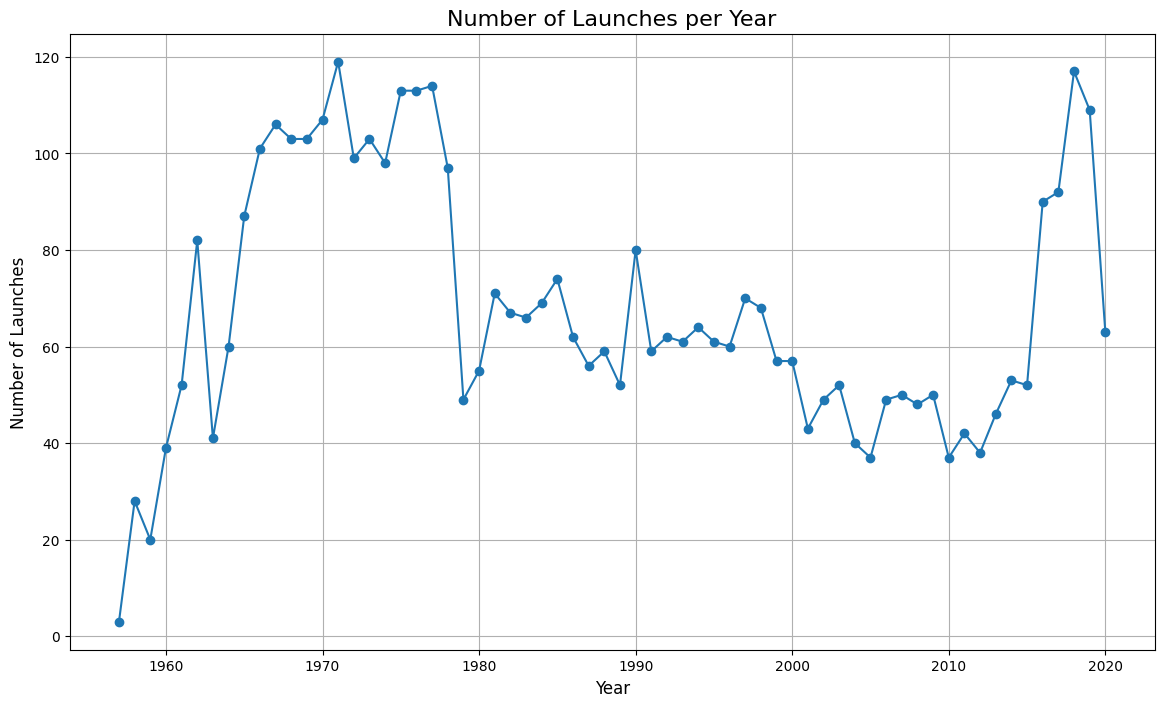

In [93]:
plt.figure(figsize=(14, 8))
plt.plot(launches_per_year.index, launches_per_year.values, marker='o', linestyle='-')
plt.title('Number of Launches per Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.grid(True)
plt.show()

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

In [94]:
monthly_launches = df_data.groupby(df_data['DateTime'].dt.to_period('M')).size()
monthly_launches.index = monthly_launches.index.to_timestamp()
rolling_avg = monthly_launches.rolling(window=12).mean()

/tmp/ipython-input-1337008016.py:1: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



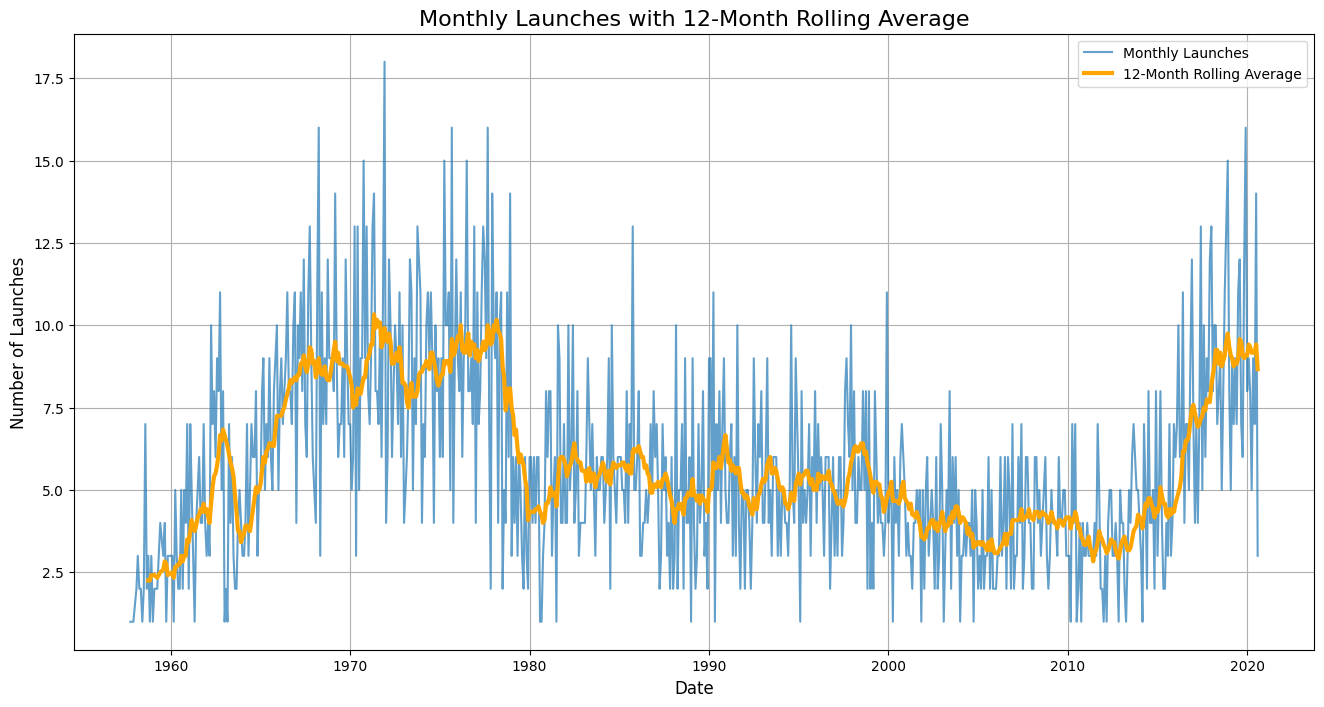

In [95]:
plt.figure(figsize=(16, 8))
plt.title('Monthly Launches with 12-Month Rolling Average', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)

plt.plot(monthly_launches.index, monthly_launches.values, label='Monthly Launches', alpha=0.7)
plt.plot(rolling_avg.index, rolling_avg.values, label='12-Month Rolling Average', color='orange', linewidth=3)

plt.legend()
plt.grid(True)
plt.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [96]:
monthly_popularity = df_data['Month'].value_counts()
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_popularity = monthly_popularity.reindex(months_order)

/tmp/ipython-input-3767864417.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




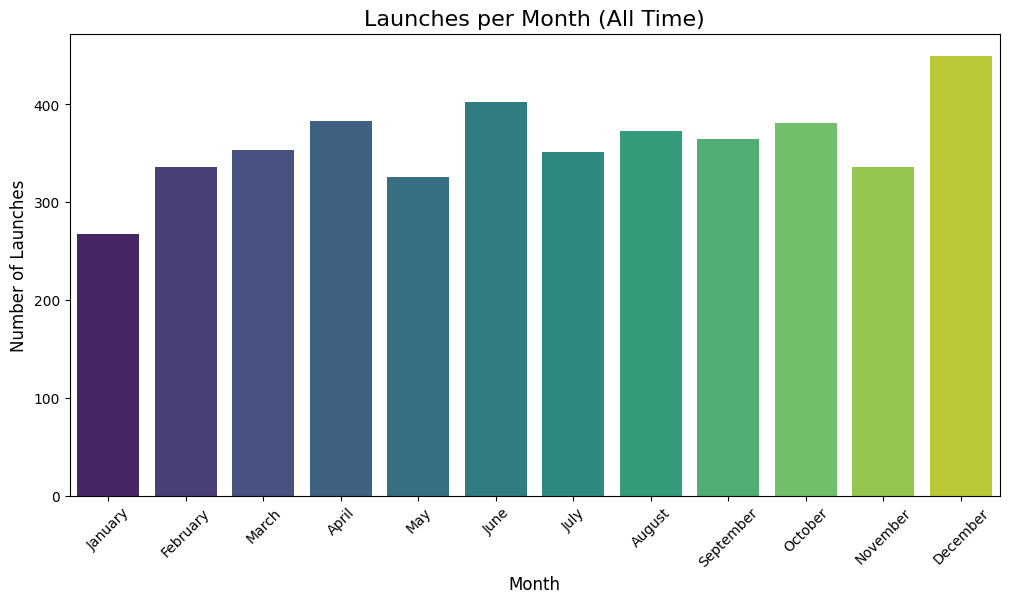

In [97]:
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_popularity.index, y=monthly_popularity.values, palette='viridis')
plt.title('Launches per Month (All Time)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# How has the Launch Price varied Over Time?

Create a line chart that shows the average price of rocket launches over time.

In [98]:
avg_price_per_year = df_data.groupby('Year')['Price'].mean()

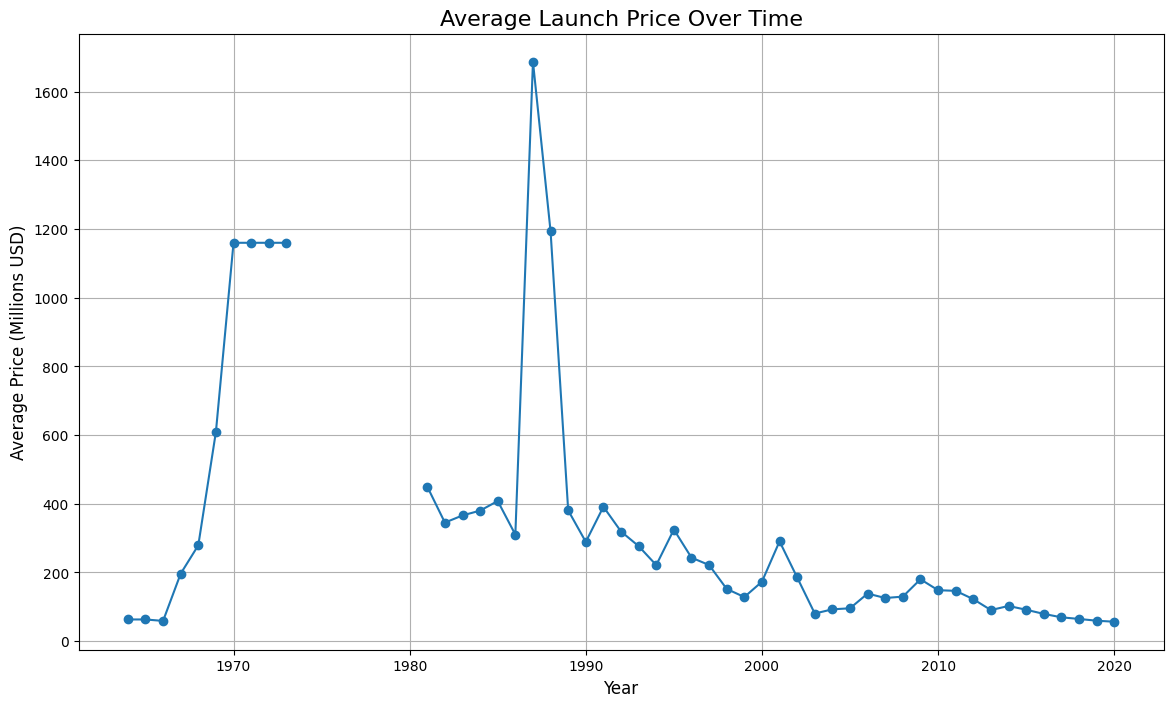

In [99]:
plt.figure(figsize=(14, 8))
plt.plot(avg_price_per_year.index, avg_price_per_year.values, marker='o', linestyle='-')
plt.title('Average Launch Price Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price (Millions USD)', fontsize=12)
plt.grid(True)
plt.show()

# Chart the Number of Launches over Time by the Top 10 Organisations.

How has the dominance of launches changed over time between the different players?

In [100]:
top_10_orgs = df_data['Organisation'].value_counts().nlargest(10).index.tolist()
df_top_10 = df_data[df_data['Organisation'].isin(top_10_orgs)]
launches_by_org_year = df_top_10.groupby(['Year', 'Organisation']).size().reset_index(name='Launches')

In [101]:
fig = px.line(launches_by_org_year,
              x='Year',
              y='Launches',
              color='Organisation',
              title='Number of Launches Over Time by Top 10 Organisations')
fig.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991.

In [102]:
df_cold_war = df_data[df_data['Year'] <= 1991].copy()

In [103]:
ussr_countries = ['Russian Federation', 'Kazakhstan', 'Ukraine']
df_cold_war['Superpower'] = np.where(df_cold_war['Country'] == 'USA', 'USA', np.where(df_cold_war['Country'].isin(ussr_countries), 'USSR', 'Other'))

In [104]:
df_race = df_cold_war[df_cold_war['Superpower'].isin(['USA', 'USSR'])]
cold_war_counts = df_race['Superpower'].value_counts()

In [105]:
fig = px.pie(values=cold_war_counts.values,
             names=cold_war_counts.index,
             title='Total Launches During Cold War: USA vs USSR')
fig.show()

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches.

In [119]:
fig = px.pie(values=cold_war_counts.values,
             names=cold_war_counts.index,
             title='Total Launches During Cold War: USA vs USSR',
             color_discrete_map={'USA':'blue', 'USSR':'red'})

fig.update_traces(textposition='inside', textinfo='percent+label+value')
fig.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [106]:
yearly_race = df_race.groupby(['Year', 'Superpower']).size().unstack(fill_value=0)

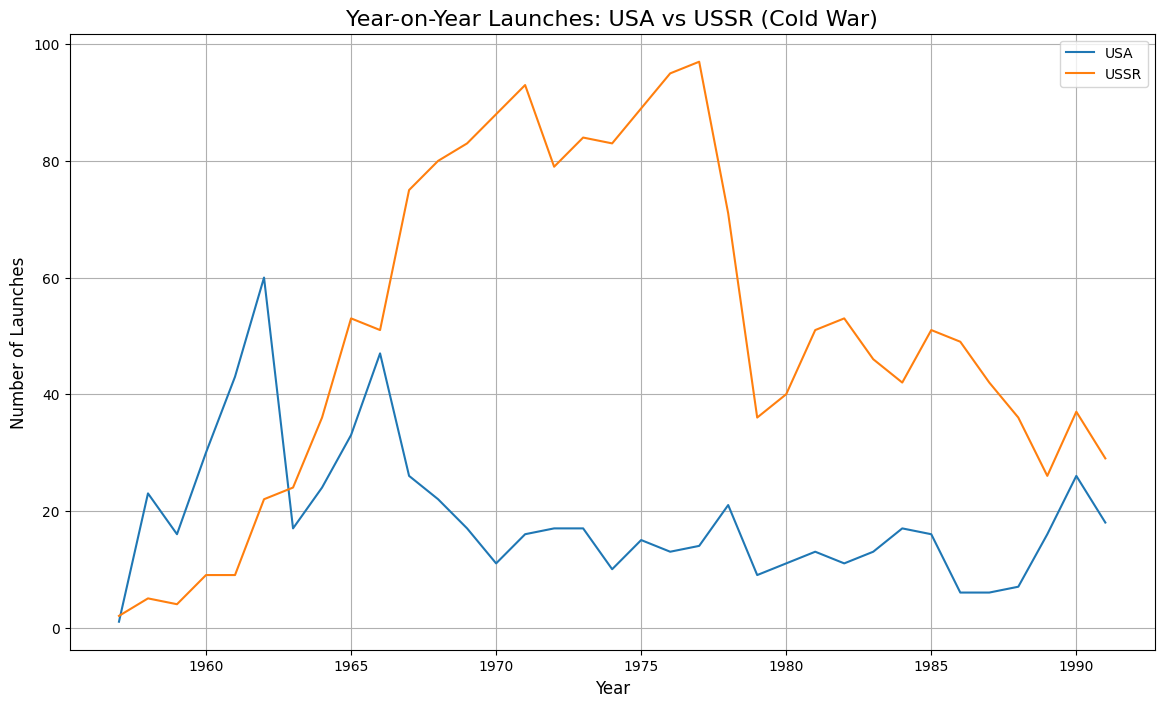

In [107]:
plt.figure(figsize=(14, 8))
plt.plot(yearly_race.index, yearly_race['USA'], label='USA')
plt.plot(yearly_race.index, yearly_race['USSR'], label='USSR')
plt.title('Year-on-Year Launches: USA vs USSR (Cold War)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

## Chart the Total Number of Mission Failures Year on Year.

In [108]:
df_failures_race = df_race[df_race['Mission_Status'].isin(['Failure', 'Partial Failure', 'Prelaunch Failure'])]
yearly_failures = df_failures_race.groupby(['Year', 'Superpower']).size().unstack(fill_value=0)

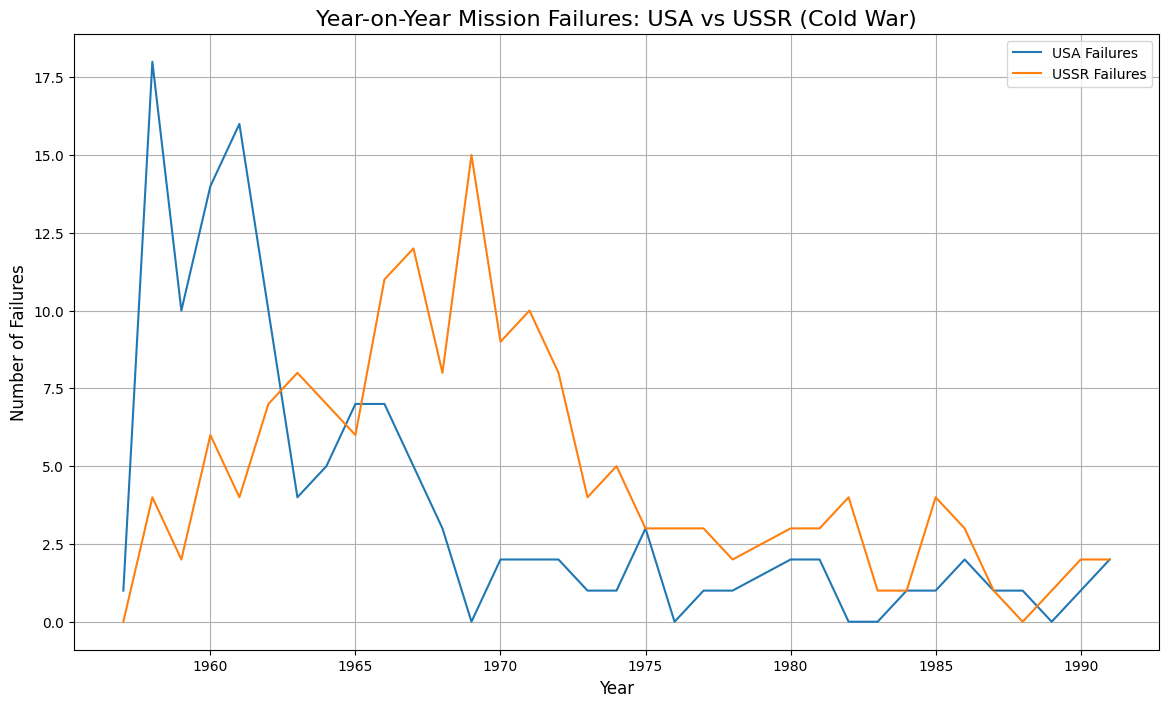

In [109]:
plt.figure(figsize=(14, 8))
plt.plot(yearly_failures.index, yearly_failures.get('USA', pd.Series(0, index=yearly_failures.index)), label='USA Failures')
plt.plot(yearly_failures.index, yearly_failures.get('USSR', pd.Series(0, index=yearly_failures.index)), label='USSR Failures')
plt.title('Year-on-Year Mission Failures: USA vs USSR (Cold War)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Failures', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time?

In [110]:
all_years = pd.DataFrame(index=pd.RangeIndex(start=yearly_race.index.min(), stop=yearly_race.index.max() + 1))
yearly_race_all = all_years.join(yearly_race).fillna(0)
yearly_failures_all = all_years.join(yearly_failures).fillna(0)

In [111]:
failure_rate_usa = (yearly_failures_all['USA'] / yearly_race_all['USA']) * 100
failure_rate_ussr = (yearly_failures_all['USSR'] / yearly_race_all['USSR']) * 100

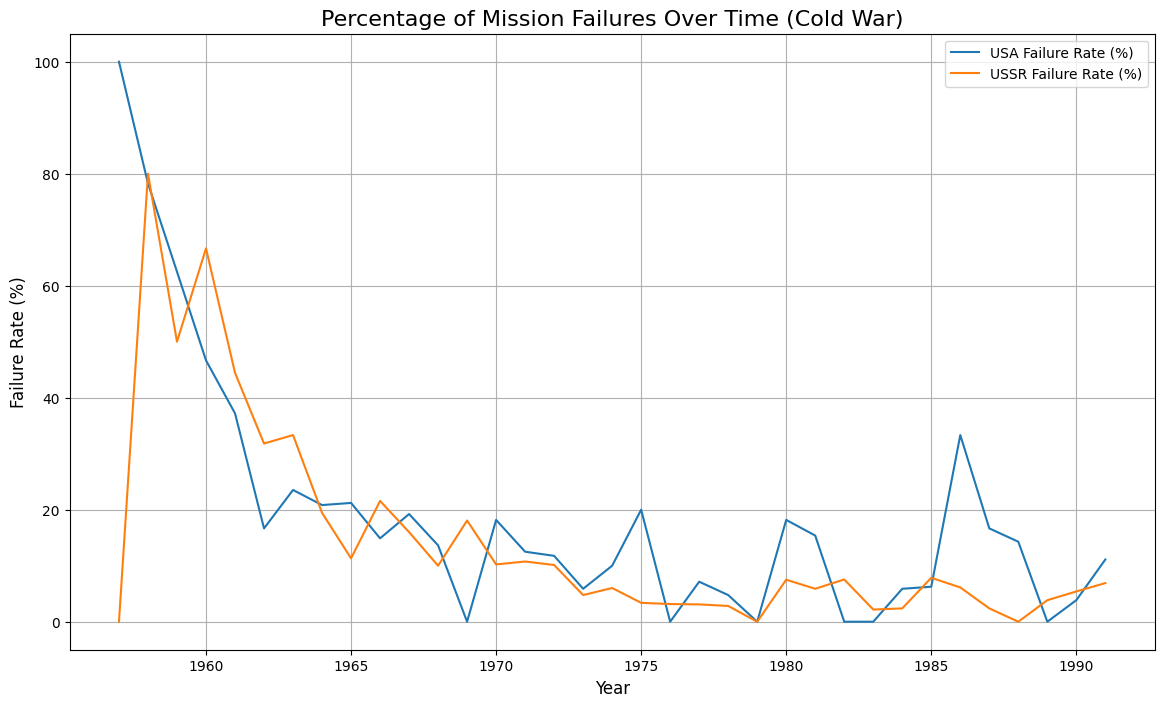

In [112]:
plt.figure(figsize=(14, 8))
plt.plot(failure_rate_usa.index, failure_rate_usa.values, label='USA Failure Rate (%)')
plt.plot(failure_rate_ussr.index, failure_rate_ussr.values, label='USSR Failure Rate (%)')
plt.title('Percentage of Mission Failures Over Time (Cold War)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Failure Rate (%)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches?

In [113]:
df_launches = df_data.groupby(['Country', 'Year']).size().reset_index(name='Launches')
df_launches['Total_Launches'] = df_launches.groupby('Country')['Launches'].cumsum()

In [114]:
cumulative_launches = df_launches.pivot(index='Year', columns='Country', values='Total_Launches').fillna(method='ffill').fillna(0)

/tmp/ipython-input-2716946737.py:1: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [115]:
top_countries = df_data['Country'].value_counts().nlargest(5).index.tolist()
cumulative_top_countries = cumulative_launches[top_countries]

In [116]:
fig = px.area(cumulative_top_countries,
              x=cumulative_top_countries.index,
              y=cumulative_top_countries.columns,
              title='Cumulative Number of Launches by Country Over Time',
              labels={'value': 'Total Launches', 'Year': 'Year'})
fig.show()

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020?

In [117]:
launches_per_org_year = df_data.groupby(['Year', 'Organisation']).size().reset_index(name='count')
dominant_org_per_year = launches_per_org_year.loc[launches_per_org_year.groupby('Year')['count'].idxmax()]

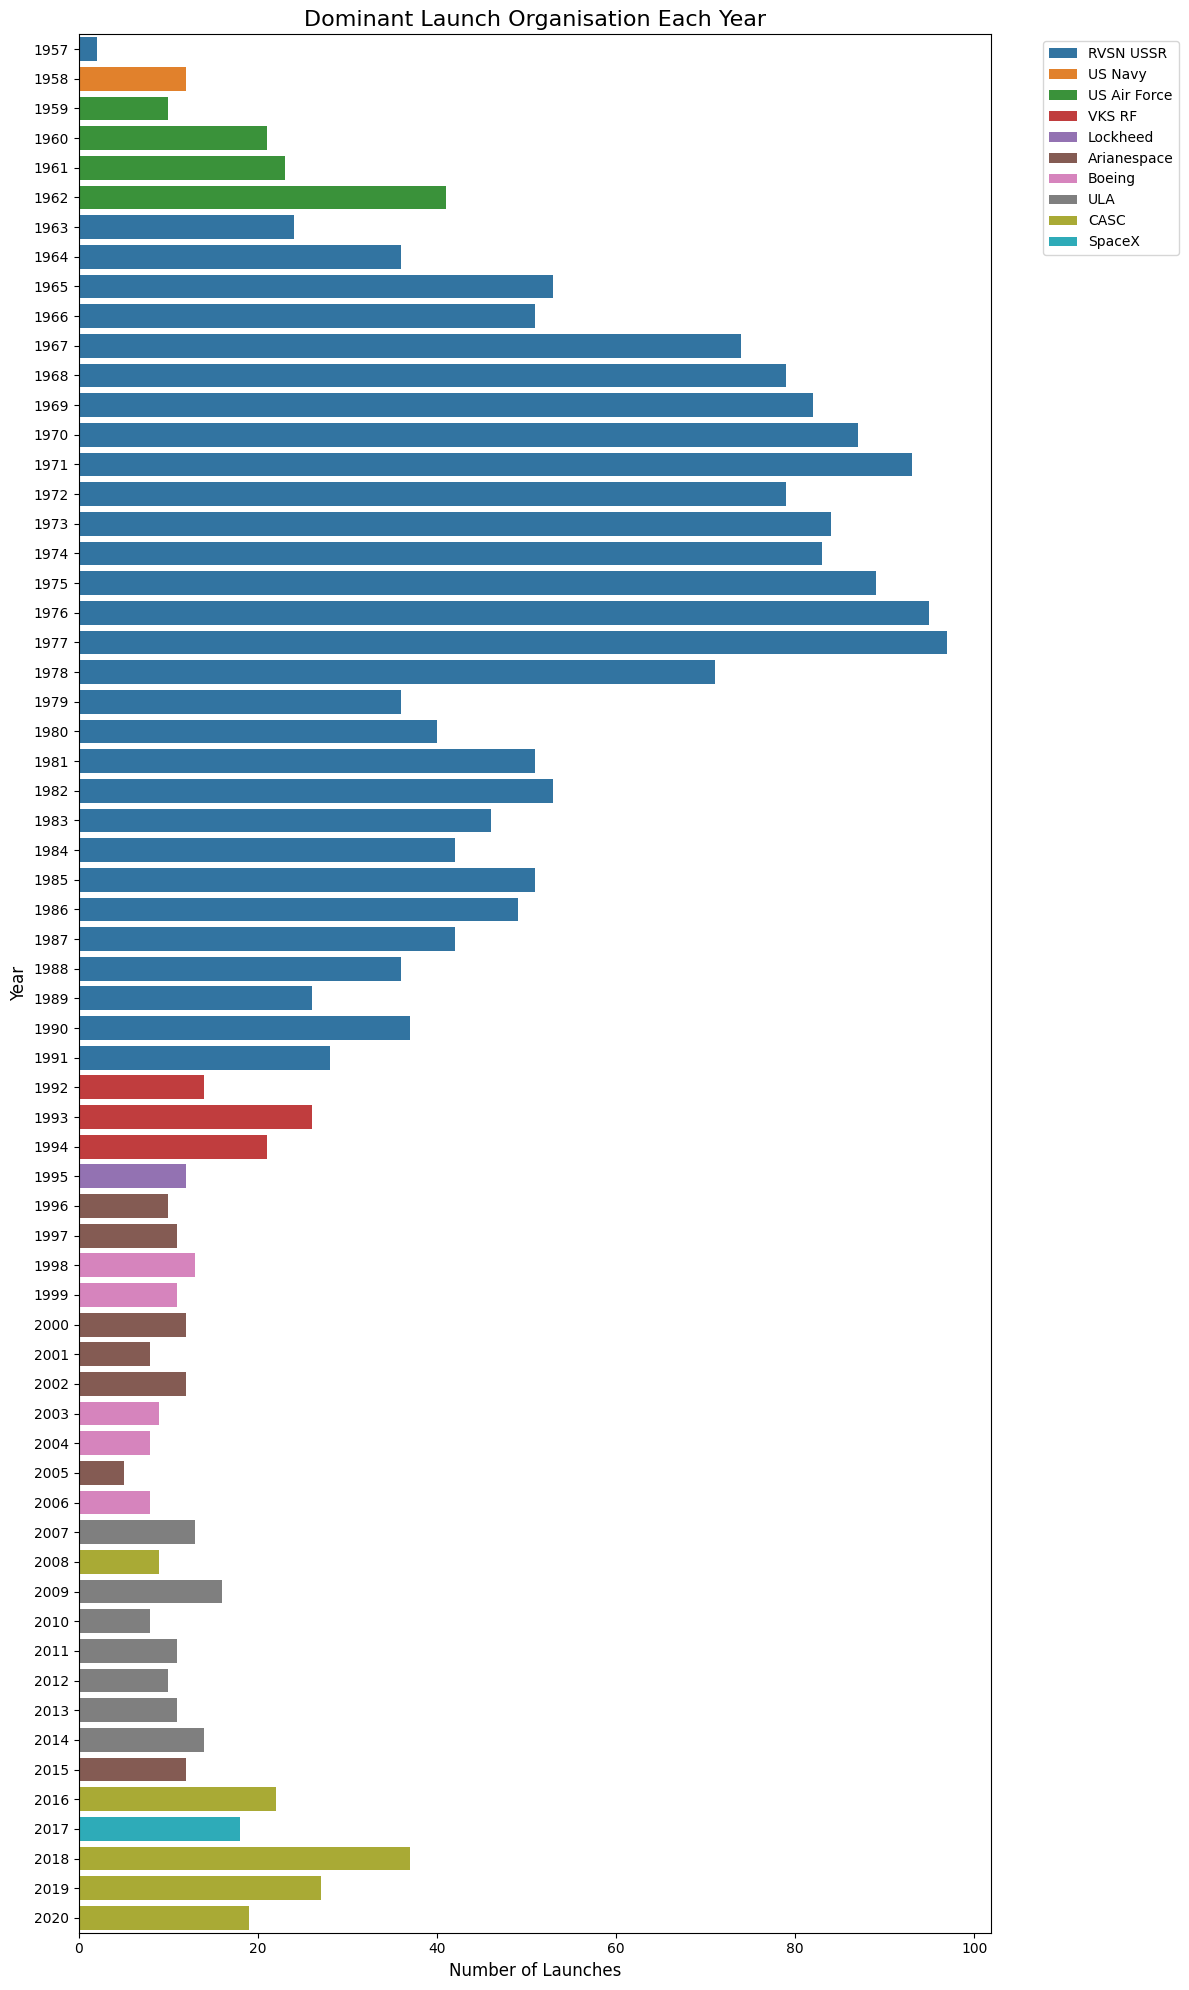

In [118]:
plt.figure(figsize=(12, 20))
sns.barplot(data=dominant_org_per_year, x='count', y='Year', hue='Organisation', dodge=False, orient='h')
plt.title('Dominant Launch Organisation Each Year', fontsize=16)
plt.xlabel('Number of Launches', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()